In [11]:
import pandas as pd

df = pd.read_csv("climate_change_impact_on_agriculture_2024.csv")
print(df.head())



   Year Country         Region  Crop_Type  Average_Temperature_C  \
0  2001   India    West Bengal       Corn                   1.55   
1  2024   China          North       Corn                   3.23   
2  2001  France  Ile-de-France      Wheat                  21.11   
3  2001  Canada       Prairies     Coffee                  27.85   
4  1998   India     Tamil Nadu  Sugarcane                   2.19   

   Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
0                  447.06             15.22                 1.737   
1                 2913.57             29.82                 1.737   
2                 1301.74             25.75                 1.719   
3                 1154.36             13.91                 3.890   
4                 1627.48             11.81                 1.080   

   Extreme_Weather_Events  Irrigation_Access_%  Pesticide_Use_KG_per_HA  \
0                       8                14.54                    10.08   
1                       8 

In [12]:

print(df.shape)
print(df.columns)
df.info()

(10000, 15)
Index(['Year', 'Country', 'Region', 'Crop_Type', 'Average_Temperature_C',
       'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Crop_Yield_MT_per_HA',
       'Extreme_Weather_Events', 'Irrigation_Access_%',
       'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA',
       'Soil_Health_Index', 'Adaptation_Strategies',
       'Economic_Impact_Million_USD'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  object 
 2   Region                       10000 non-null  object 
 3   Crop_Type                    10000 non-null  object 
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT            

In [13]:
print(df.isnull().sum())


Year                           0
Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
dtype: int64


In [14]:

print(df.duplicated().sum())


0


In [15]:

df.drop_duplicates(inplace=True)


In [16]:

print(df.dtypes)


Year                             int64
Country                         object
Region                          object
Crop_Type                       object
Average_Temperature_C          float64
Total_Precipitation_mm         float64
CO2_Emissions_MT               float64
Crop_Yield_MT_per_HA           float64
Extreme_Weather_Events           int64
Irrigation_Access_%            float64
Pesticide_Use_KG_per_HA        float64
Fertilizer_Use_KG_per_HA       float64
Soil_Health_Index              float64
Adaptation_Strategies           object
Economic_Impact_Million_USD    float64
dtype: object


In [17]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Country',
    'Region',
    'Crop_Type',
    'Adaptation_Strategies'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])



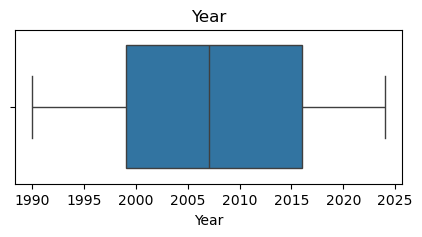

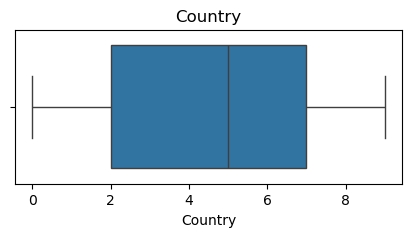

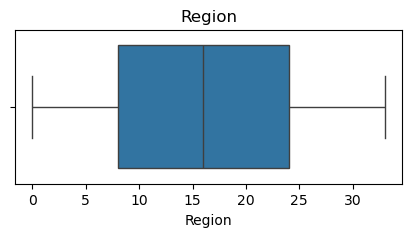

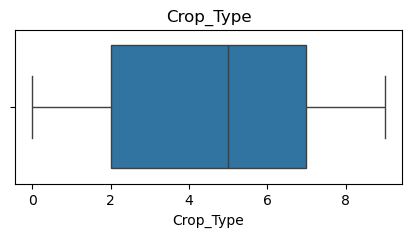

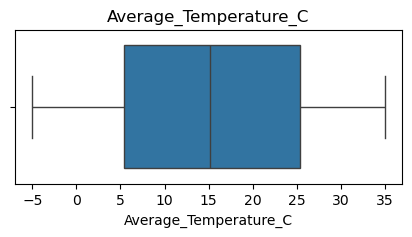

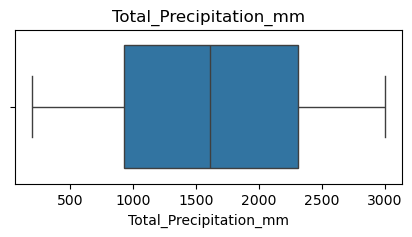

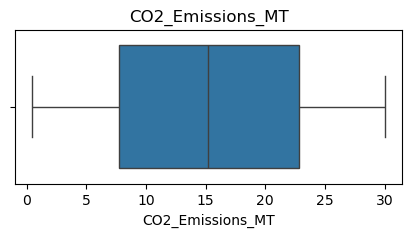

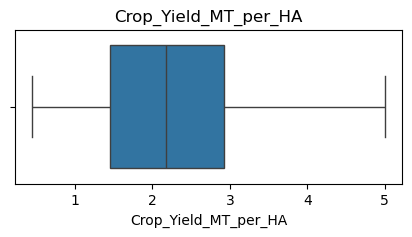

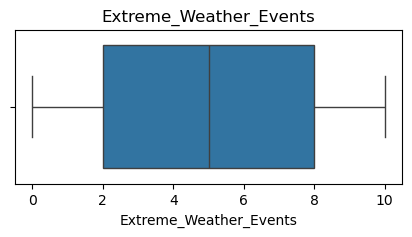

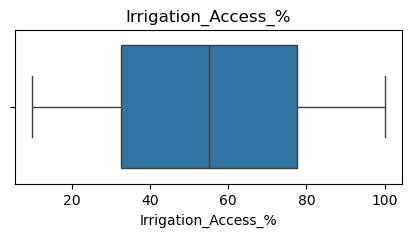

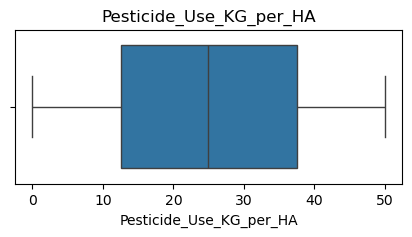

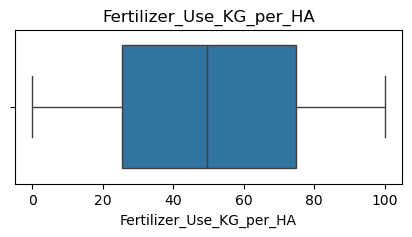

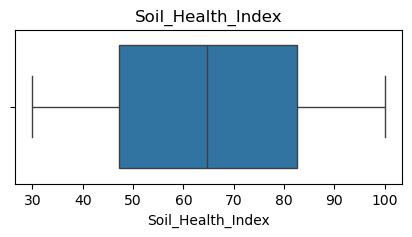

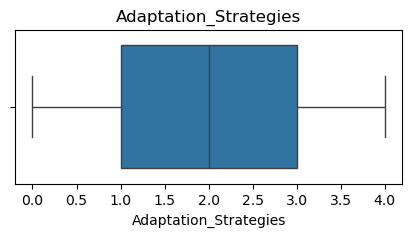

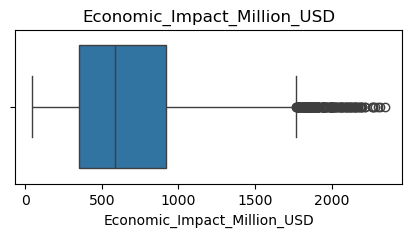

In [18]:

import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(
    include=['int64','float64']
).columns

for col in numerical_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [19]:

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print("Before:", df.shape)
print("After:", df.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = [
    'Average_Temperature_C',
    'Total_Precipitation_mm',
    'CO2_Emissions_MT',
    'Extreme_Weather_Events',
    'Irrigation_Access_%',
    'Pesticide_Use_KG_per_HA',
    'Fertilizer_Use_KG_per_HA',
    'Soil_Health_Index',
    'Economic_Impact_Million_USD'
]

df[numerical_cols] = scaler.fit_transform(
    df[numerical_cols]
)
print(df.shape)

print(df.head())

print(df.describe())



Before: (9823, 15)
After: (9823, 15)
(9823, 15)
   Year  Country  Region  Crop_Type  Average_Temperature_C  \
0  2001        6      32          2              -1.183203   
1  2024        4       8          2              -1.037644   
2  2001        5       4          9               0.511515   
3  2001        3      18          1               1.095483   
4  1998        6      28          7              -1.127752   

   Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
0               -1.443129         -0.006217                 1.737   
1                1.616976          1.692823                 1.737   
2               -0.382760          1.219186                 1.719   
3               -0.565609         -0.158666                 3.890   
4                0.021373         -0.403048                 1.080   

   Extreme_Weather_Events  Irrigation_Access_%  Pesticide_Use_KG_per_HA  \
0                0.953810            -1.565384                -1.024986   
1             


Objective 1


In [20]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("climate_change_impact_on_agriculture_2024.csv")
print(df.head())


   Year Country         Region  Crop_Type  Average_Temperature_C  \
0  2001   India    West Bengal       Corn                   1.55   
1  2024   China          North       Corn                   3.23   
2  2001  France  Ile-de-France      Wheat                  21.11   
3  2001  Canada       Prairies     Coffee                  27.85   
4  1998   India     Tamil Nadu  Sugarcane                   2.19   

   Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
0                  447.06             15.22                 1.737   
1                 2913.57             29.82                 1.737   
2                 1301.74             25.75                 1.719   
3                 1154.36             13.91                 3.890   
4                 1627.48             11.81                 1.080   

   Extreme_Weather_Events  Irrigation_Access_%  Pesticide_Use_KG_per_HA  \
0                       8                14.54                    10.08   
1                       8 

In [21]:


num_cols = [
    'Average_Temperature_C',
    'Total_Precipitation_mm',
    'CO2_Emissions_MT',
    'Crop_Yield_MT_per_HA',
    'Irrigation_Access_%',
    'Soil_Health_Index'
]

corr_matrix = df[num_cols].corr()

print(corr_matrix)


                        Average_Temperature_C  Total_Precipitation_mm  \
Average_Temperature_C                1.000000                0.007213   
Total_Precipitation_mm               0.007213                1.000000   
CO2_Emissions_MT                    -0.003052               -0.008681   
Crop_Yield_MT_per_HA                 0.263781                0.029728   
Irrigation_Access_%                 -0.013268               -0.007580   
Soil_Health_Index                   -0.010841               -0.021621   

                        CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
Average_Temperature_C          -0.003052              0.263781   
Total_Precipitation_mm         -0.008681              0.029728   
CO2_Emissions_MT                1.000000             -0.089868   
Crop_Yield_MT_per_HA           -0.089868              1.000000   
Irrigation_Access_%             0.002995             -0.000255   
Soil_Health_Index               0.004518             -0.005692   

                        I

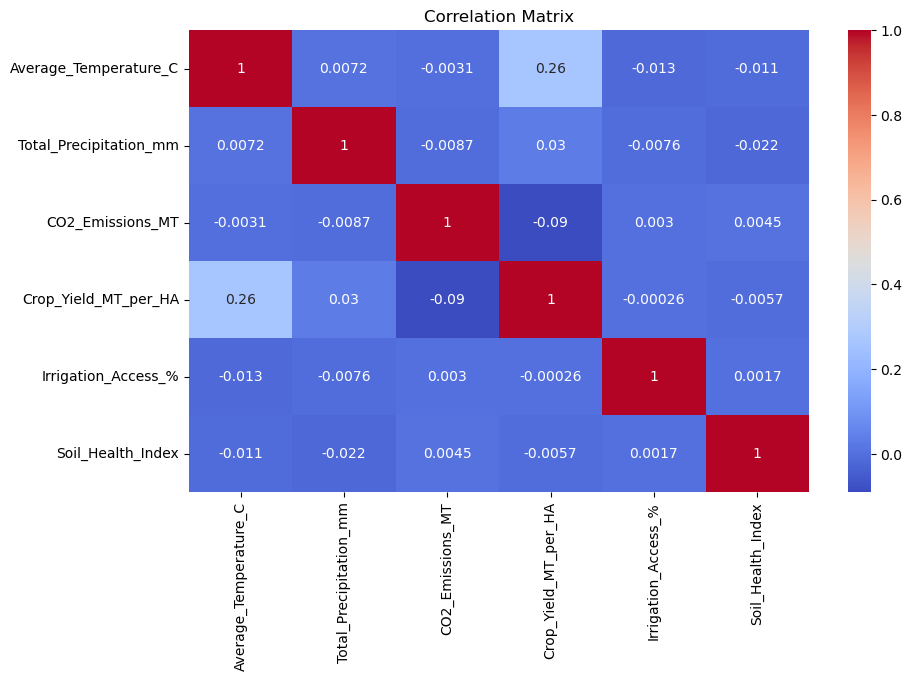

In [22]:

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


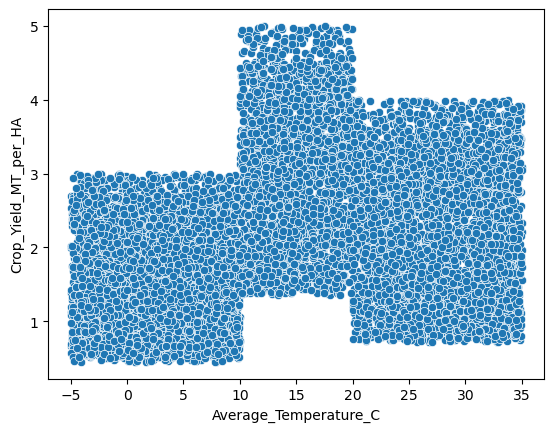

In [23]:

sns.scatterplot(
    x='Average_Temperature_C',
    y='Crop_Yield_MT_per_HA',
    data=df
)
plt.show()


In [24]:

df[['Average_Temperature_C',
    'Total_Precipitation_mm',
    'CO2_Emissions_MT',
    'Crop_Yield_MT_per_HA']].describe()



,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.241299,1611.663834,15.246608,2.240017
std,11.466955,805.016815,8.589423,0.998342
min,-4.990000,200.150000,0.500000,0.450000
25%,5.430000,925.697500,7.760000,1.449000
50%,15.175000,1611.160000,15.200000,2.170000
75%,25.340000,2306.997500,22.820000,2.930000
max,35.000000,2999.670000,30.000000,5.000000


In [25]:

from scipy.stats import pearsonr

variables = [
    'Average_Temperature_C',
    'Total_Precipitation_mm',
    'CO2_Emissions_MT',
    'Extreme_Weather_Events',
    'Irrigation_Access_%',
    'Soil_Health_Index'
]

for var in variables:
    corr, p = pearsonr(df[var], df['Crop_Yield_MT_per_HA'])

    print(f"\nVariable: {var}")
    print("Correlation:", corr)
    print("P-value:", p)




Variable: Average_Temperature_C
Correlation: 0.26378072469850977
P-value: 8.054273780398374e-159

Variable: Total_Precipitation_mm
Correlation: 0.029727512427541618
P-value: 0.002948692503763827

Variable: CO2_Emissions_MT
Correlation: -0.08986822609281449
P-value: 2.177950123928271e-19

Variable: Extreme_Weather_Events
Correlation: -0.005093686506521601
P-value: 0.6105361553614679

Variable: Irrigation_Access_%
Correlation: -0.00025521476268806345
P-value: 0.9796415628651718

Variable: Soil_Health_Index
Correlation: -0.0056924479895368
P-value: 0.5692351792189959



Objective 2


In [26]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Average_Temperature_C',
        'Total_Precipitation_mm',
        'CO2_Emissions_MT',
        'Irrigation_Access_%',
        'Soil_Health_Index']]

y = df['Crop_Yield_MT_per_HA']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

model = LinearRegression()

model.fit(X_train,y_train)

coefficients = pd.DataFrame({
    'Variable':X.columns,
    'Coefficient':model.coef_
})

print(coefficients)


                 Variable  Coefficient
0   Average_Temperature_C     0.023155
1  Total_Precipitation_mm     0.000041
2        CO2_Emissions_MT    -0.009614
3     Irrigation_Access_%     0.000035
4       Soil_Health_Index     0.000102


In [27]:

from sklearn.metrics import r2_score

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))


R2 Score: 0.06788867347758543


In [28]:

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)


RMSE: 0.9918756625858567


In [29]:

from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, pred))


MAE: 0.8140948768637695


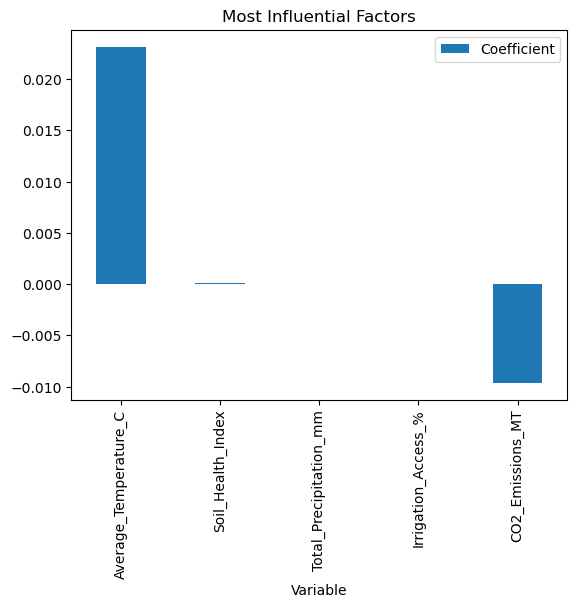

In [30]:

coefficients.sort_values(
    by='Coefficient',
    ascending=False
).plot(
    x='Variable',
    y='Coefficient',
    kind='bar'
)

plt.title("Most Influential Factors")
plt.show()


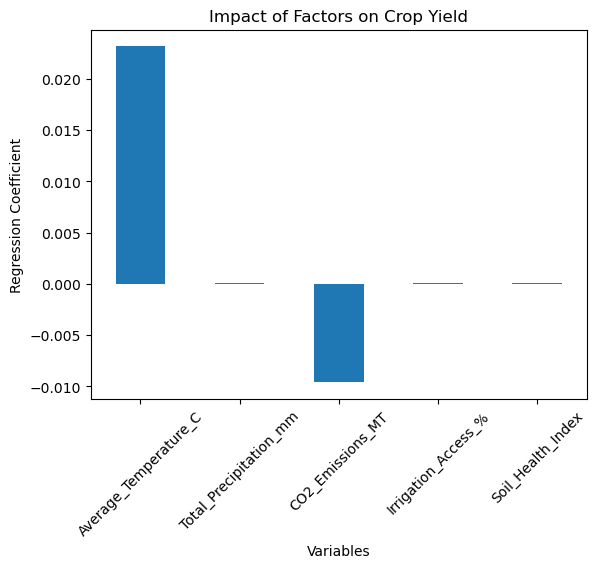

In [31]:

import matplotlib.pyplot as plt

coefficients.plot(
    x='Variable',
    y='Coefficient',
    kind='bar',
    legend=False
)

plt.title("Impact of Factors on Crop Yield")
plt.xlabel("Variables")
plt.ylabel("Regression Coefficient")
plt.xticks(rotation=45)
plt.show()



Objective 3


In [32]:

from scipy.stats import f_oneway

group_variables = [
    'Country',
    'Region',
    'Crop_Type',
    'Adaptation_Strategies'
]

for var in group_variables:

    groups = [
        group['Crop_Yield_MT_per_HA'].values
        for name, group in df.groupby(var)
    ]

    f_stat, p_value = f_oneway(*groups)

    print("\n---------------------------")
    print("Variable:", var)
    print("F Statistic:", f_stat)
    print("P Value:", p_value)

    if p_value < 0.05:
        print("Significant difference exists")
    else:
        print("No significant difference")




---------------------------
Variable: Country
F Statistic: 0.4532027888679393
P Value: 0.9061078133719443
No significant difference

---------------------------
Variable: Region
F Statistic: 0.8976602211193448
P Value: 0.6359426004849086
No significant difference

---------------------------
Variable: Crop_Type
F Statistic: 1.4774326341922457
P Value: 0.14980268942043723
No significant difference

---------------------------
Variable: Adaptation_Strategies
F Statistic: 0.9851567841197221
P Value: 0.4141532542532954
No significant difference


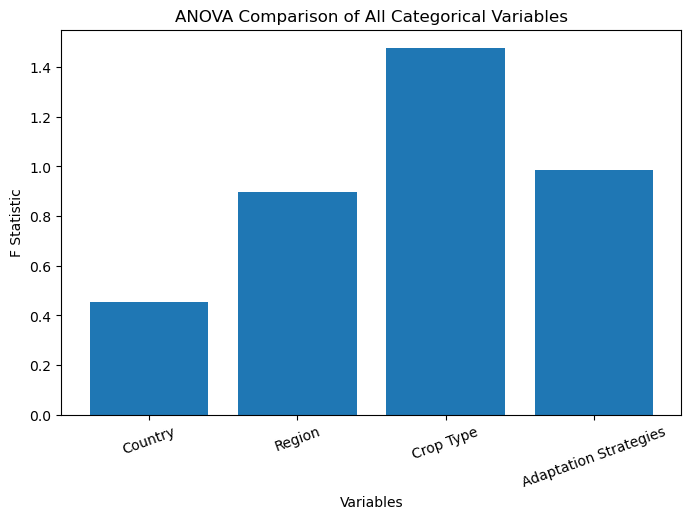

In [55]:
import matplotlib.pyplot as plt

anova_results = pd.DataFrame({
    'Variable': ['Country', 'Region', 'Crop Type', 'Adaptation Strategies'],
    'F_Statistic': [0.4532, 0.8977, 1.4774, 0.9852]
})

plt.figure(figsize=(8,5))

plt.bar(
    anova_results['Variable'],
    anova_results['F_Statistic']
)

plt.title('ANOVA Comparison of All Categorical Variables')
plt.xlabel('Variables')
plt.ylabel('F Statistic')

plt.xticks(rotation=20)
plt.show()

In [63]:

from scipy.stats import f_oneway

for var in categorical_vars:

    grand_mean = df['Crop_Yield_MT_per_HA'].mean()

    ss_between = sum(
        len(group) *
        (group['Crop_Yield_MT_per_HA'].mean() - grand_mean)**2
        for name, group in df.groupby(var)
    )

    ss_total = sum(
        (df['Crop_Yield_MT_per_HA'] - grand_mean)**2
    )

    eta_squared = ss_between / ss_total

    print(f"{var} : Eta Squared = {eta_squared:.5f}")


Country : Eta Squared = 0.00041
Region : Eta Squared = 0.00296
Crop_Type : Eta Squared = 0.00133
Adaptation_Strategies : Eta Squared = 0.00039


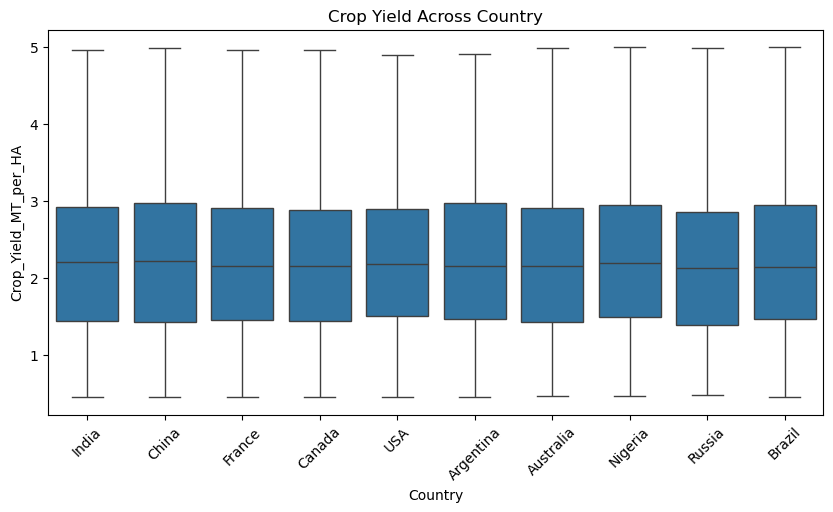

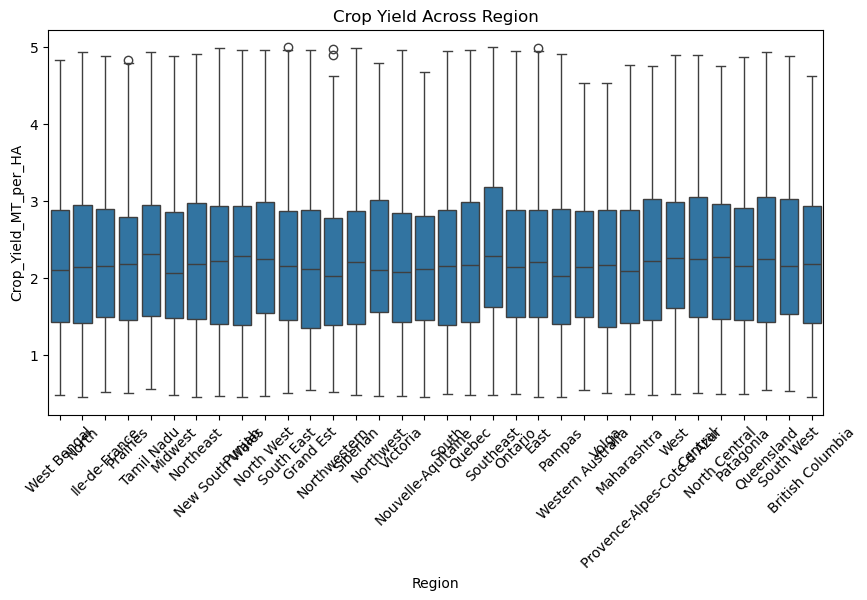

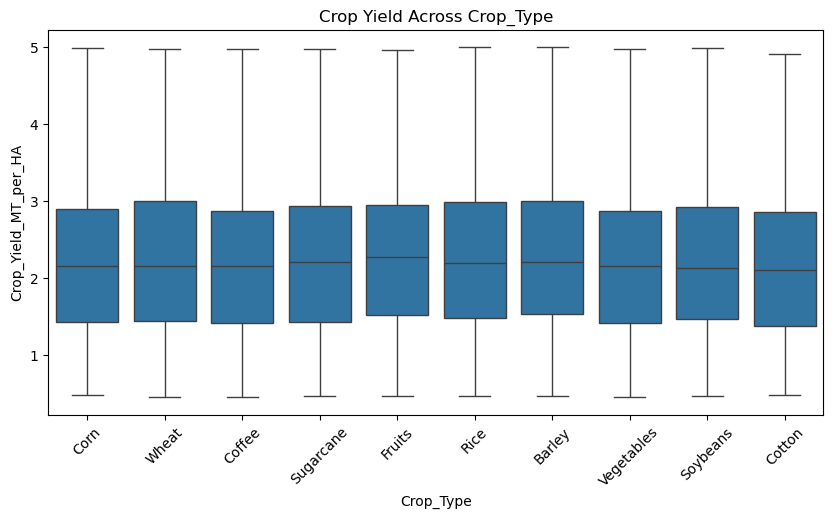

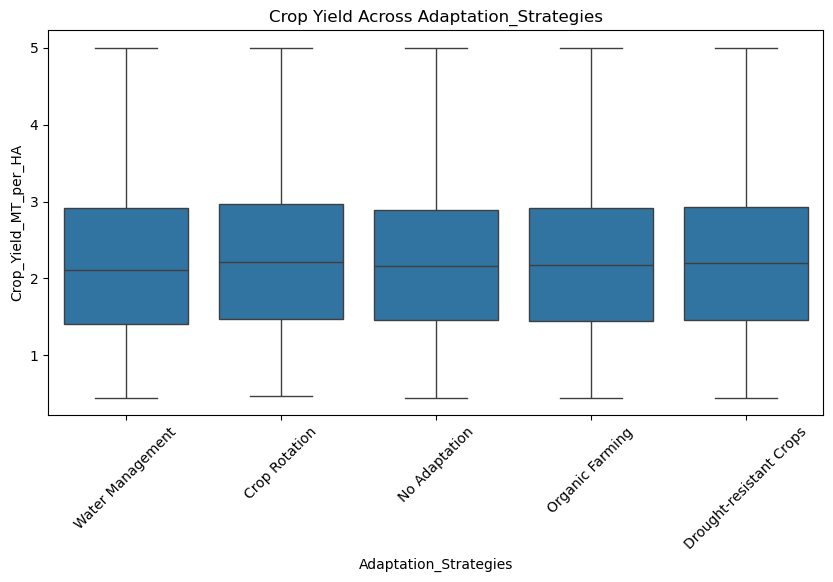

In [64]:

import seaborn as sns
import matplotlib.pyplot as plt

categorical_vars = [
    'Country',
    'Region',
    'Crop_Type',
    'Adaptation_Strategies'
]

for var in categorical_vars:

    plt.figure(figsize=(10,5))

    sns.boxplot(
        x=var,
        y='Crop_Yield_MT_per_HA',
        data=df
    )

    plt.title(f'Crop Yield Across {var}')
    plt.xticks(rotation=45)

    plt.show()



Objective 4


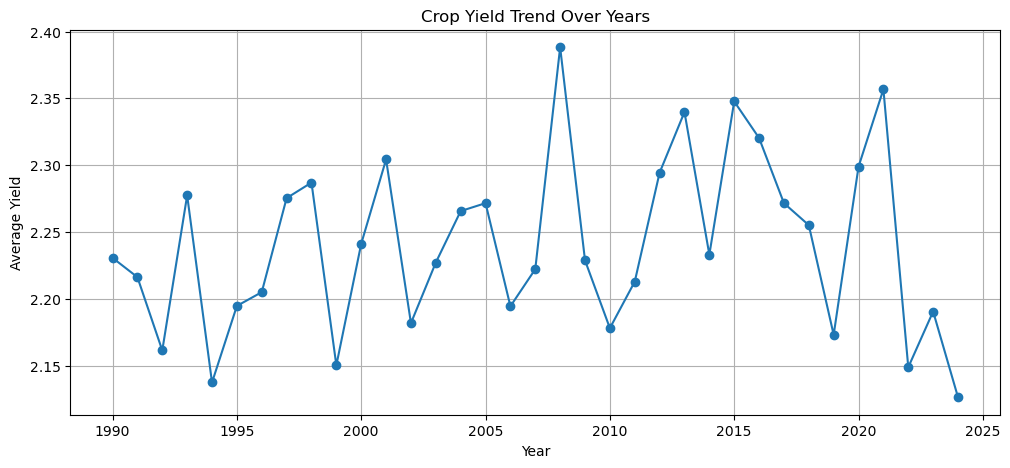

In [65]:



yield_trend = df.groupby('Year')[
    'Crop_Yield_MT_per_HA'
].mean()

plt.figure(figsize=(12,5))

yield_trend.plot(marker='o')

plt.title("Crop Yield Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Yield")

plt.grid(True)

plt.show()


In [66]:

from scipy.stats import pearsonr

corr, p = pearsonr(df['Year'], df['Crop_Yield_MT_per_HA'])

print("Correlation:", corr)
print("P-value:", p)



Correlation: 0.010734311989200293
P-value: 0.28312400691012374


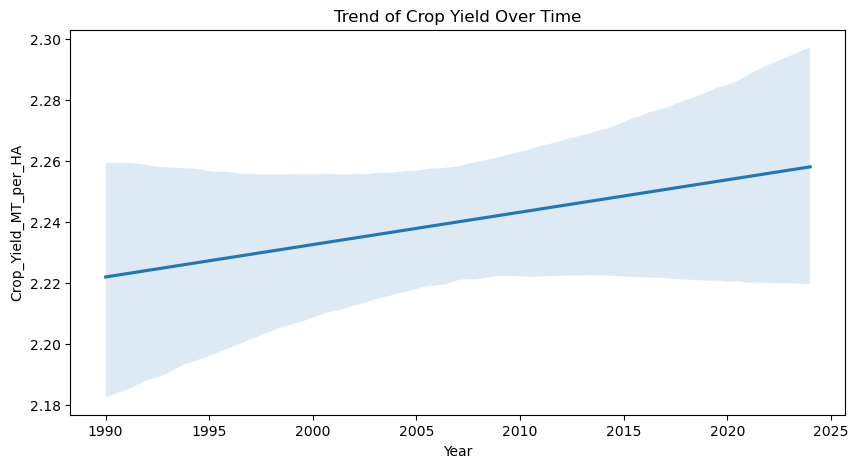

In [67]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.regplot(
    x='Year',
    y='Crop_Yield_MT_per_HA',
    data=df,
    scatter=False
)

plt.title('Trend of Crop Yield Over Time')
plt.show()




Objective 5


In [68]:

from scipy.stats import kruskal

# Create groups based on adaptation strategies
groups = [
    group['Crop_Yield_MT_per_HA'].values
    for name, group in df.groupby('Adaptation_Strategies')
]

# Kruskal-Wallis Test
stat, p_value = kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant difference exists among adaptation strategies")
else:
    print("No significant difference among adaptation strategies")


Kruskal-Wallis Statistic: 4.190972642004051
P-value: 0.3807770308503223
No significant difference among adaptation strategies


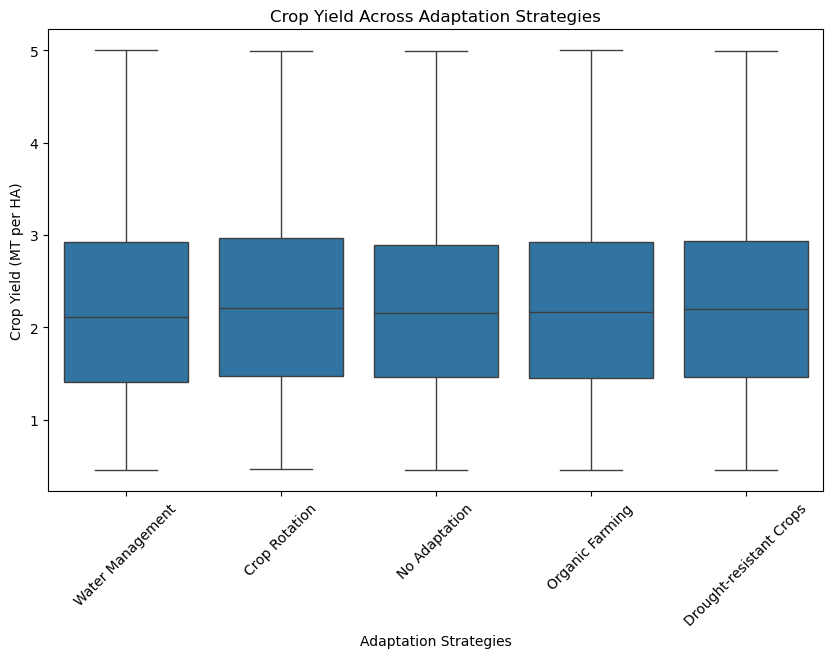

In [69]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Adaptation_Strategies',
    y='Crop_Yield_MT_per_HA',
    data=df
)

plt.title('Crop Yield Across Adaptation Strategies')
plt.xlabel('Adaptation Strategies')
plt.ylabel('Crop Yield (MT per HA)')
plt.xticks(rotation=45)

plt.show()

